# Plant Disease Classifier
## Step 7: Predict on New Images

**What you will learn in this notebook:**
- How to preprocess a single new image
- How to run one image through the trained model
- How to interpret the output confidence score
- Build predict.py for standalone predictions
- Build main.py to tie everything together

---


---
## Cell 1: Import Libraries

In [1]:
import os
import sys
import torch
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image

sys.path.append('../src')
from model import build_model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Device : {device}')
print('All imports successful.')

Device : cuda
All imports successful.


---
## Cell 2: Load the Trained Model

In [2]:
MODEL_PATH = '../outputs/best_model.pth'

model = build_model(num_classes=2, device=device)
model.load_state_dict(
    torch.load(MODEL_PATH, map_location=device, weights_only=True)
)
model.eval()

print('Model loaded and ready for prediction.')

Model loaded and ready for prediction.


---
## Cell 3: Define the Prediction Transform

Any new image must go through the same preprocessing as training images.
We use val_transforms (no augmentation, just resize and normalize).

In [3]:
# Same transforms used during validation and testing
predict_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

# Class labels
CLASS_NAMES = ['Healthy', 'Diseased']

print('Prediction transform defined.')
print()
print('Pipeline for new image:')
print('  1. Resize to 224x224')
print('  2. Convert to tensor')
print('  3. Normalize with ImageNet stats')
print('  4. Add batch dimension [1, 3, 224, 224]')
print('  5. Feed through model')
print('  6. Apply softmax to get probabilities')

Prediction transform defined.

Pipeline for new image:
  1. Resize to 224x224
  2. Convert to tensor
  3. Normalize with ImageNet stats
  4. Add batch dimension [1, 3, 224, 224]
  5. Feed through model
  6. Apply softmax to get probabilities


---
## Cell 4: Build the Predict Function

This function takes an image path and returns the prediction and confidence.

In [4]:
def predict(image_path, model, transform, device, class_names):
    """
    Predicts whether a leaf image is Healthy or Diseased.

    Args:
        image_path  : path to the leaf image file
        model       : trained MobileNetV3 model
        transform   : preprocessing pipeline
        device      : cuda or cpu
        class_names : list of class names ['Healthy', 'Diseased']

    Returns:
        predicted_class : 'Healthy' or 'Diseased'
        confidence      : confidence percentage (0-100)
        probabilities   : full probability array
    """

    # Step 1: Load image
    image = Image.open(image_path).convert('RGB')

    # Step 2: Apply transforms
    tensor = transform(image)             # shape: [3, 224, 224]

    # Step 3: Add batch dimension
    tensor = tensor.unsqueeze(0)          # shape: [1, 3, 224, 224]

    # Step 4: Move to device
    tensor = tensor.to(device)

    # Step 5: Forward pass
    model.eval()
    with torch.no_grad():
        output = model(tensor)            # shape: [1, 2]

    # Step 6: Convert to probabilities
    probabilities = torch.softmax(output, dim=1)[0]  # shape: [2]

    # Step 7: Get predicted class
    pred_idx         = probabilities.argmax().item()
    predicted_class  = class_names[pred_idx]
    confidence       = probabilities[pred_idx].item() * 100

    return predicted_class, confidence, probabilities.cpu().numpy()


print('predict() function defined.')

predict() function defined.


---
## Cell 5: Test on a Sample Image from the Dataset

Before testing on a completely new image, let us test on one image from our dataset to verify everything works.

In [5]:
DATA_DIR = '../data/PlantVillage'

# Pick one healthy image and one diseased image
healthy_folder  = 'Tomato_healthy'
diseased_folder = 'Tomato_Early_blight'

healthy_img_path  = os.path.join(DATA_DIR, healthy_folder,
                    os.listdir(os.path.join(DATA_DIR, healthy_folder))[0])
diseased_img_path = os.path.join(DATA_DIR, diseased_folder,
                    os.listdir(os.path.join(DATA_DIR, diseased_folder))[0])

# Predict on both
for img_path, true_label in [(healthy_img_path, 'Healthy'), (diseased_img_path, 'Diseased')]:
    pred_class, confidence, probs = predict(
        img_path, model, predict_transform, device, CLASS_NAMES
    )
    correct = 'CORRECT' if pred_class == true_label else 'WRONG'
    print(f'Image      : {os.path.basename(img_path)}')
    print(f'True label : {true_label}')
    print(f'Prediction : {pred_class}  ({confidence:.2f}% confident)  {correct}')
    print(f'Healthy={probs[0]*100:.2f}%  Diseased={probs[1]*100:.2f}%')
    print()

Image      : 000146ff-92a4-4db6-90ad-8fce2ae4fddd___GH_HL Leaf 259.1.JPG
True label : Healthy
Prediction : Healthy  (99.97% confident)  CORRECT
Healthy=99.97%  Diseased=0.03%

Image      : 0012b9d2-2130-4a06-a834-b1f3af34f57e___RS_Erly.B 8389.JPG
True label : Diseased
Prediction : Diseased  (100.00% confident)  CORRECT
Healthy=0.00%  Diseased=100.00%



---
## Cell 6: Visualize the Predictions

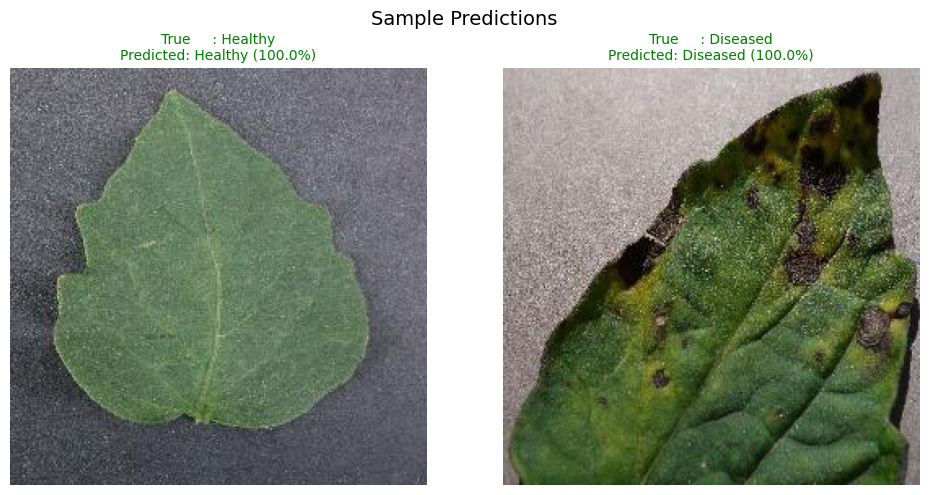

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Sample Predictions', fontsize=14)

for ax, (img_path, true_label) in zip(axes, [
    (healthy_img_path, 'Healthy'),
    (diseased_img_path, 'Diseased')
]):
    pred_class, confidence, probs = predict(
        img_path, model, predict_transform, device, CLASS_NAMES
    )
    correct = pred_class == true_label
    color   = 'green' if correct else 'red'

    img = Image.open(img_path).convert('RGB')
    ax.imshow(img)
    ax.set_title(
        f'True     : {true_label}\n'
        f'Predicted: {pred_class} ({confidence:.1f}%)',
        color=color, fontsize=10
    )
    ax.axis('off')

plt.tight_layout()
plt.show()

---
## Cell 7: Test on a Completely New Image

Now test on any leaf image from outside the dataset.
You can download any plant leaf image from Google and test it here.

Prediction Result
Image      : ../sample1.jpg
Prediction : Diseased
Confidence : 96.29%
Healthy    : 3.71%
Diseased   : 96.29%


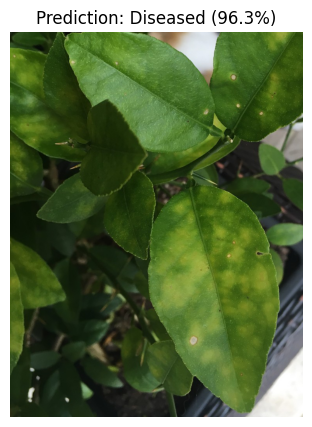

In [11]:
# Place any leaf image in your notebooks folder and update this path
# Example: NEW_IMAGE_PATH = '../my_leaf.jpg'

NEW_IMAGE_PATH = '../sample1.jpg'   # <-- change this to your image path

if not os.path.exists(NEW_IMAGE_PATH):
    print('Image not found at:', NEW_IMAGE_PATH)
    print()
    print('To test on a new image:')
    print('  1. Download any plant leaf image from Google')
    print('  2. Save it to your plant-disease-classifier folder')
    print('  3. Update NEW_IMAGE_PATH above')
    print('  4. Re-run this cell')
else:
    pred_class, confidence, probs = predict(
        NEW_IMAGE_PATH, model, predict_transform, device, CLASS_NAMES
    )

    print('Prediction Result')
    print('=' * 40)
    print(f'Image      : {NEW_IMAGE_PATH}')
    print(f'Prediction : {pred_class}')
    print(f'Confidence : {confidence:.2f}%')
    print(f'Healthy    : {probs[0]*100:.2f}%')
    print(f'Diseased   : {probs[1]*100:.2f}%')

    img = Image.open(NEW_IMAGE_PATH).convert('RGB')
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f'Prediction: {pred_class} ({confidence:.1f}%)', fontsize=12)
    plt.axis('off')
    plt.show()

---
## Cell 8: Save predict.py

In [12]:
predict_code = '''
import sys
import torch
from torchvision import transforms
from PIL import Image

sys.path.append('./src')
from model import build_model

CLASS_NAMES = ['Healthy', 'Diseased']

predict_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])


def predict(image_path, model_path='./outputs/best_model.pth'):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model = build_model(num_classes=2, device=device)
    model.load_state_dict(
        torch.load(model_path, map_location=device, weights_only=True)
    )
    model.eval()

    image  = Image.open(image_path).convert("RGB")
    tensor = predict_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(tensor)

    probs      = torch.softmax(output, dim=1)[0]
    pred_idx   = probs.argmax().item()
    pred_class = CLASS_NAMES[pred_idx]
    confidence = probs[pred_idx].item() * 100

    return pred_class, confidence


if __name__ == "__main__":
    import sys
    if len(sys.argv) < 2:
        print("Usage: python predict.py path/to/leaf_image.jpg")
    else:
        image_path = sys.argv[1]
        pred, conf = predict(image_path)
        print(f"Prediction : {pred}")
        print(f"Confidence : {conf:.2f}%")
'''

with open('../predict.py', 'w') as f:
    f.write(predict_code)

print('predict.py saved successfully.')

predict.py saved successfully.


---
## Cell 9: Save main.py

In [13]:
main_code = '''
import os
import sys
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import StepLR

sys.path.append('./src')
from dataset  import get_dataloaders
from model    import build_model
from train    import train_one_epoch, validate
from evaluate import evaluate, print_metrics


# Config
DATA_DIR   = './data/PlantVillage'
MODEL_PATH = './outputs/best_model.pth'
BATCH_SIZE = 32
NUM_EPOCHS = 10
LR         = 0.001

os.makedirs('./outputs/results', exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Load data
print('Loading data...')
train_loader, val_loader, test_loader, class_names = get_dataloaders(
    data_dir=DATA_DIR, batch_size=BATCH_SIZE
)

# Build model
print('Building model...')
model     = build_model(num_classes=2, device=device)
criterion = nn.CrossEntropyLoss()
optimizer = Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)
scheduler = StepLR(optimizer, step_size=5, gamma=0.1)

# Train
print(f'Training for {NUM_EPOCHS} epochs...')
best_val_acc = 0.0
for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss,   val_acc   = validate(model, val_loader, criterion, device)
    scheduler.step()
    print(f'Epoch {epoch}/{NUM_EPOCHS}  Train Acc: {train_acc:.2f}%  Val Acc: {val_acc:.2f}%')
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), MODEL_PATH)
        print(f'  Best model saved.')

# Evaluate on test set
print()
print('Evaluating on test set...')
model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
preds, labels = evaluate(model, test_loader, device)
print_metrics(preds, labels)
'''

with open('../main.py', 'w') as f:
    f.write(main_code)

print('main.py saved successfully.')
print()
print('Step 7 Complete!')
print()
print('Your classifier is complete. You can now run:')
print('  python main.py                      to train from scratch')
print('  python predict.py path/to/leaf.jpg  to classify a new image')

main.py saved successfully.

Step 7 Complete!

Your classifier is complete. You can now run:
  python main.py                      to train from scratch
  python predict.py path/to/leaf.jpg  to classify a new image


---
## Step 7 Summary and Full Project Summary

### What predict.py does
```
python predict.py my_leaf.jpg

Prediction : Diseased
Confidence : 98.72%
```

### What main.py does
```
python main.py

Runs the full pipeline:
  1. Load dataset
  2. Build model
  3. Train for 10 epochs
  4. Save best model
  5. Evaluate on test set
  6. Print final metrics
```

---
### Full Project Results

| Metric | Score |
|--------|-------|
| Validation Accuracy | 99.68% |
| Test Accuracy | 99.58% |
| Precision | 99.54% |
| Recall | 99.96% |
| F1 Score | 99.75% |

---
### Final File Structure
```
plant-disease-classifier/
├── data/PlantVillage/         dataset
├── src/
│   ├── dataset.py             data loading
│   ├── model.py               MobileNetV3
│   ├── train.py               training loop
│   └── evaluate.py            metrics
├── outputs/
│   ├── best_model.pth         saved weights
│   └── results/
│       ├── accuracy_plot.png
│       └── confusion_matrix.png
├── notebooks/
│   ├── step2_dataset.ipynb
│   ├── step3_transfer_learning.ipynb
│   ├── step4_build_model.ipynb
│   ├── step5_train.ipynb
│   ├── step6_evaluate.ipynb
│   └── step7_predict.ipynb
├── predict.py                 classify new images
└── main.py                    run full pipeline
```